# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

In [3]:
def plot_modified_df(df_cut):
    """
    Plots the modified DataFrame with adjusted time steps.

    Parameters:
    df_cut (pd.DataFrame): The modified DataFrame with adjusted time steps.

    Returns:
    None
    """
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'], label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'], label='Normal Force (Fz)', alpha=0.7)
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Modified Tangential vs Normal Force (Adjusted Timesteps)')
    plt.grid()
    plt.show()

<font size="6">Sediment 70°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 713
Average Fx in the averaging interval [793:1506]: 5.4226110536843715
Average Fz in the averaging interval [793:1506]: 1.3838781070575474
Maximum Fz in the plotting interval [793:None]: 2.930810546875 at timestep 1494
Time step where Fx drops below 1: 1506


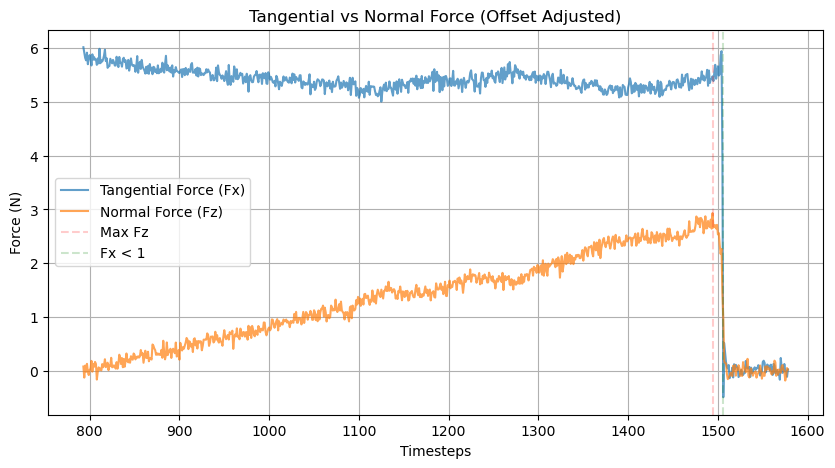

In [19]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_70_5N//log_202405231941.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=793, cut_2=None, avg_end=1506, offset_position='end', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 764
Average Fx in the averaging interval [1120:1884]: 5.277891174577709
Average Fz in the averaging interval [1120:1884]: 1.6844727574426674
Maximum Fz in the plotting interval [1120:None]: 3.789375813802083 at timestep 1864
Time step where Fx drops below 1: 1884


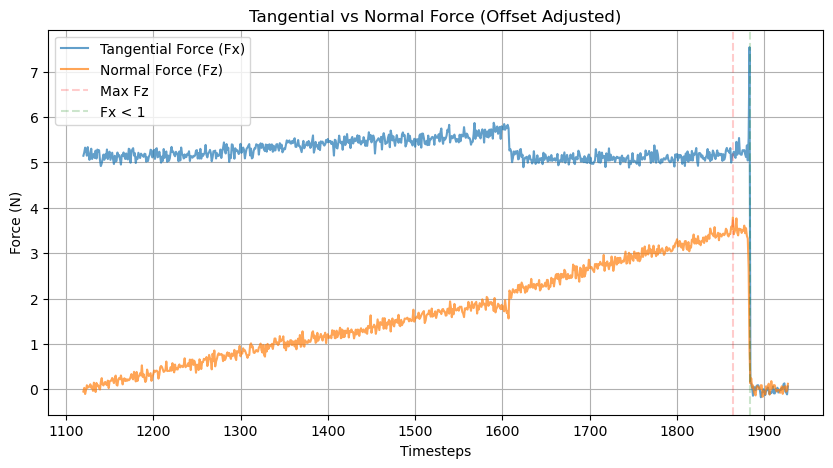

In [24]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_70_5N//log_202405231942.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=1120, cut_2=None, avg_end=1884, offset_position='end', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 121
Average Fx in the averaging interval [1350:1471]: 5.003085929303129
Average Fz in the averaging interval [1350:1471]: 0.44133324320979683
Maximum Fz in the plotting interval [1350:None]: 0.6909342447916667 at timestep 1448
Time step where Fx drops below 1: 1471


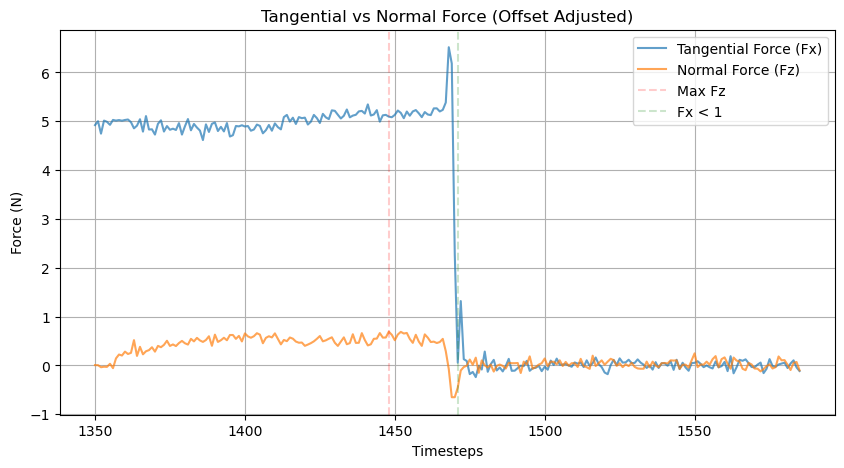

In [28]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_70_5N//log_202405231943.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=1350, cut_2=None, avg_end=1471, offset_position='end', offset_length=15)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 546
Average Fx in the averaging interval [1320:1866]: 4.636410976067567
Average Fz in the averaging interval [1320:1866]: 1.2533289200220352
Maximum Fz in the plotting interval [1320:None]: 1.9676554361979166 at timestep 1833
Time step where Fx drops below 1: 1866


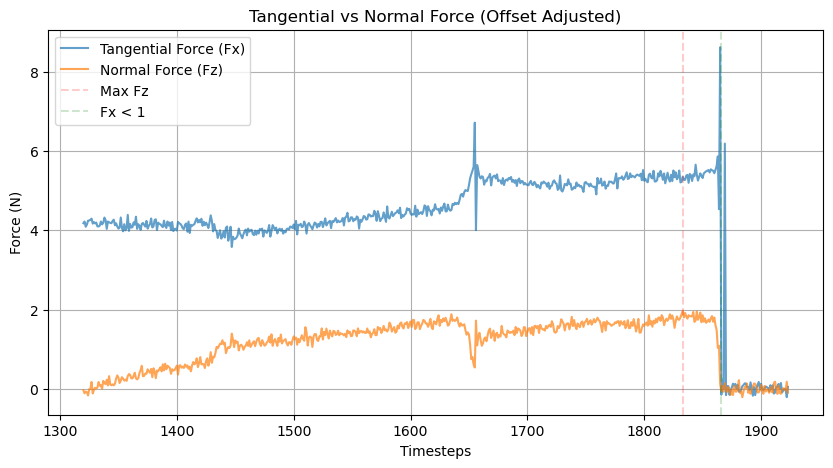

In [34]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_70_5N//log_202405231945.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=1320, cut_2=None, avg_end=1866, offset_position='end', offset_length=15)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 523
Average Fx in the averaging interval [1450:1973]: 4.388385732467194
Average Fz in the averaging interval [1450:1973]: 0.9181741299942239
Maximum Fz in the plotting interval [1450:None]: 2.0177652994791666 at timestep 1954
Time step where Fx drops below 1: 1608


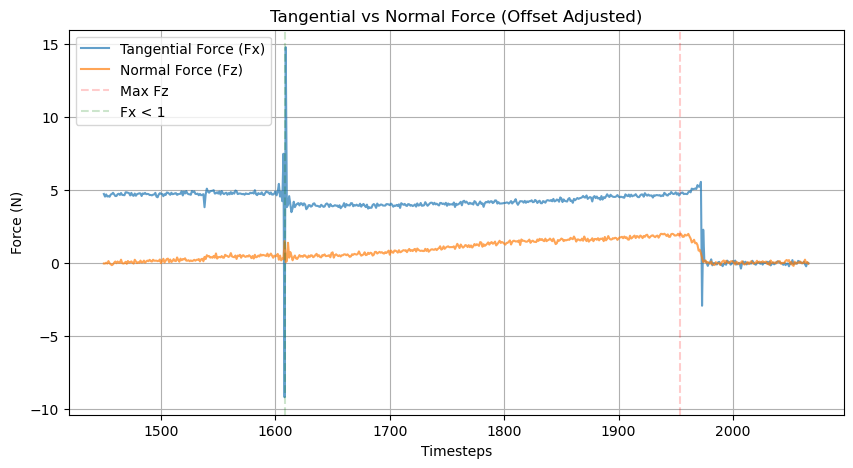

In [41]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_70_5N//log_202405231946.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=1450, cut_2=None, avg_end=1973, offset_position='end', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 561
Average Fx in the averaging interval [950:1511]: 5.517104912654176
Average Fz in the averaging interval [950:1511]: 1.2495712960255123
Maximum Fz in the plotting interval [950:None]: 2.9284423828125 at timestep 1498
Time step where Fx drops below 1: 1511


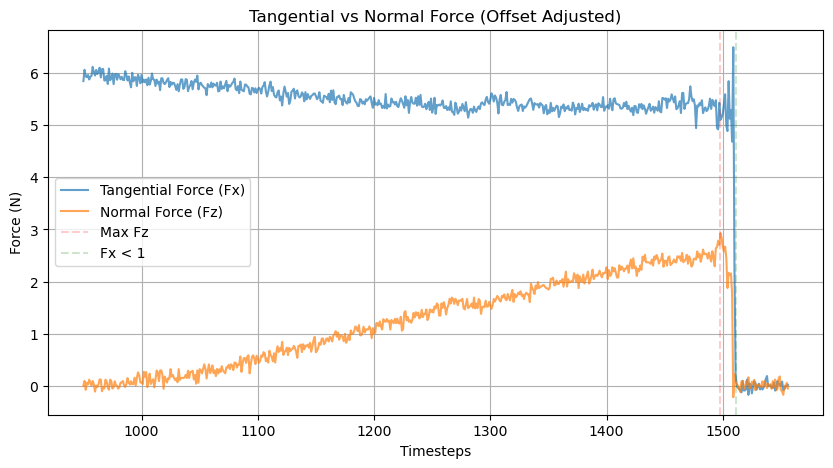

In [44]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_70_5N//log_202405231948.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=950, cut_2=None, avg_end=1511, offset_position='end', offset_length=15)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 672
Average Fx in the averaging interval [820:1492]: 5.100953845750718
Average Fz in the averaging interval [820:1492]: 1.492191369192941
Maximum Fz in the plotting interval [820:None]: 2.9132364908854167 at timestep 1475
Time step where Fx drops below 1: 1492


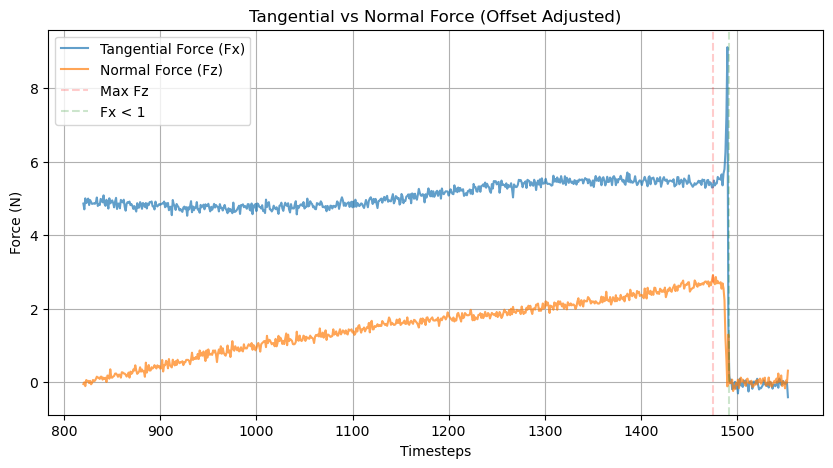

In [48]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_70_5N//log_202405231949.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=820, cut_2=None, avg_end=1492, offset_position='beginning', offset_length=15)

<font size="6">Test 8: (failed)</font>

Average Fx in the averaging interval [None:None]: 3.3348351189120464
Average Fz in the averaging interval [None:None]: -1.5985672043733274
Maximum Fz in the plotting interval [None:None]: 0.16019694010416666 at timestep 25
Time step where Fx drops below 1: 0


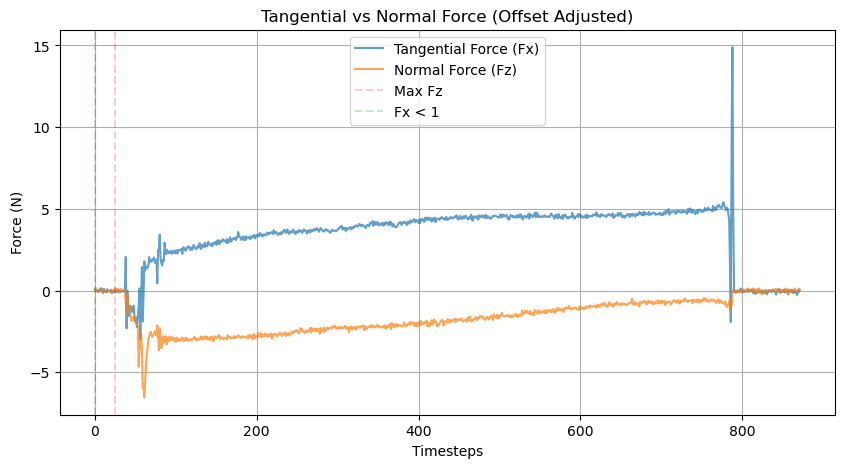

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_70_5N//log_202405231950.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 1081
Average Fx in the averaging interval [570:1651]: 4.845381762221974
Average Fz in the averaging interval [570:1651]: 1.9863700309139396
Maximum Fz in the plotting interval [570:None]: 3.8927734375 at timestep 1615
Time step where Fx drops below 1: 1651


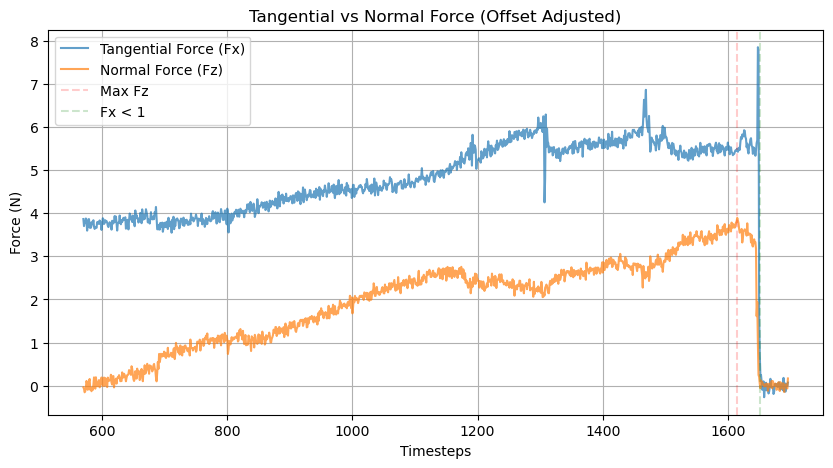

In [51]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_70_5N//log_202405231951.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=570, cut_2=None, avg_end=1651, offset_position='end', offset_length=15)

<font size="6">Test 10a: (worked)</font>

Length from cut_1 to avg_end: 386
Average Fx in the averaging interval [650:1036]: 5.198842622661426
Average Fz in the averaging interval [650:1036]: 0.6359266844438147
Maximum Fz in the plotting interval [650:1055]: 1.345477294921875 at timestep 1000
Time step where Fx drops below 1: 1036


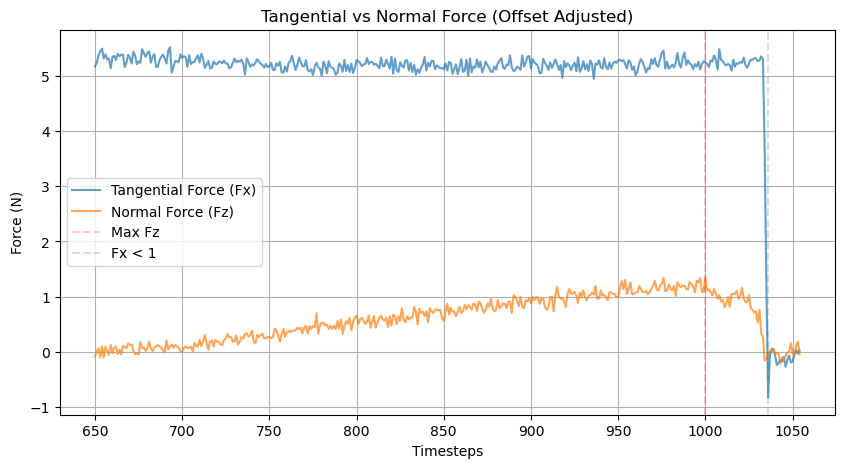

In [65]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_70_5N//log_202405231954.csv"
df = pd.read_csv(data)
test_10a, end_10a = plot_forces(df, cut_1=650, cut_2=1055, avg_end=1036, offset_position='end', offset_length=30)

<font size="6">Test 10b: (worked)</font>

Length from cut_1 to avg_end: 422
Average Fx in the averaging interval [1205:1627]: 3.2901342205150055
Average Fz in the averaging interval [1205:1627]: 0.5663946215010367
Maximum Fz in the plotting interval [1205:None]: 1.212908935546875 at timestep 1527
Time step where Fx drops below 1: 1627


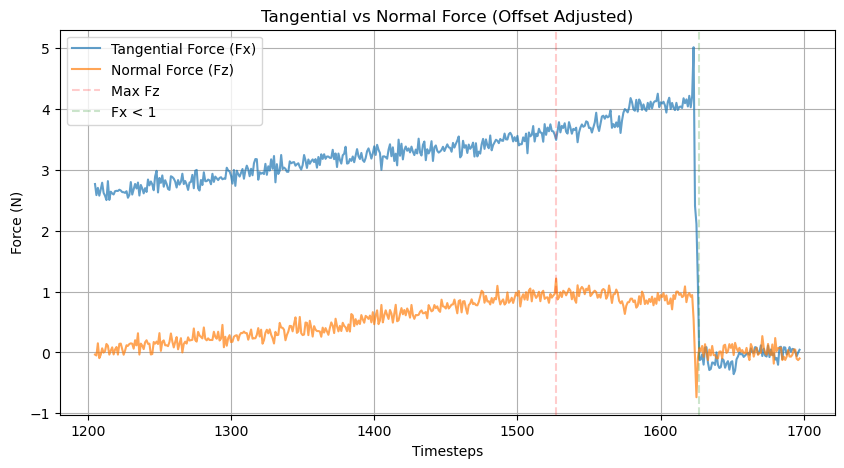

In [71]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_70_5N//log_202405231954.csv"
df = pd.read_csv(data)
test_10b, end_10b = plot_forces(df, cut_1=1205, cut_2=None, avg_end=1627, offset_position='end', offset_length=30)

In [72]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [76]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//70//Sediment_70_stats.csv", index=False)

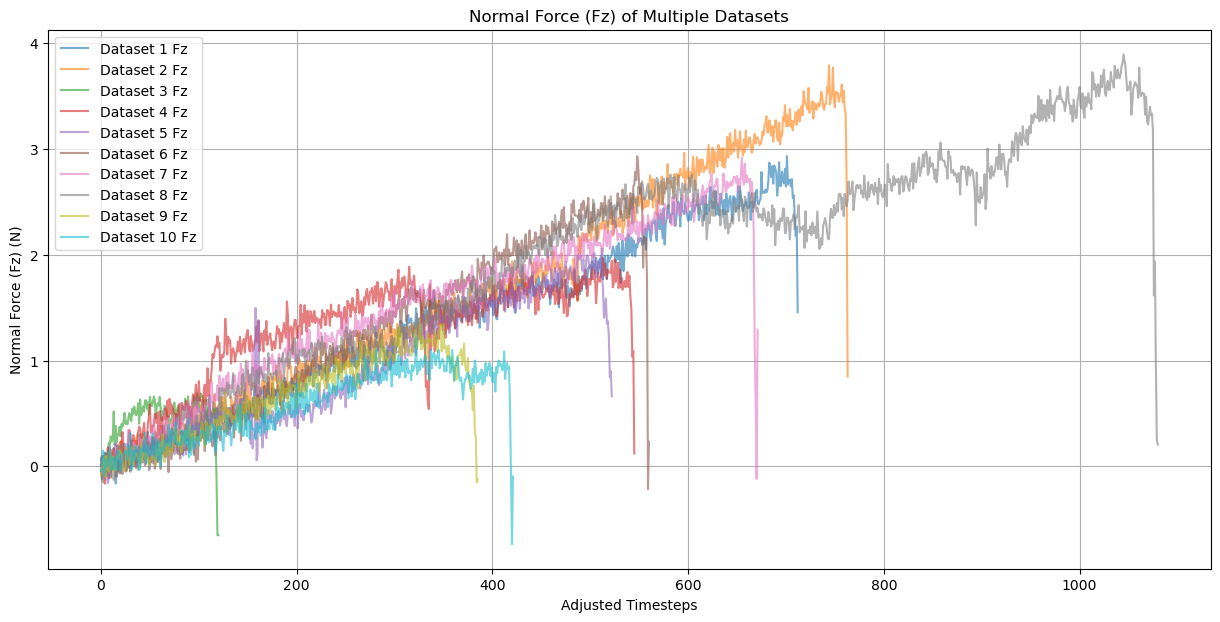

Average of maximum Fz forces: 2.3689379882812496
Standard deviation of maximum Fz forces: 1.0367567873302452
Average of average Fz forces: 1.1611641159803514
Standard deviation of average Fz forces: 0.4834390562193475
Average of average Fx forces: 4.8680802229903275
Standard deviation of average Fx forces: 0.6207051785696891


In [77]:
tests = [test_1, test_2, test_3, test_4, test_5, test_6, test_7, test_9, test_10a, test_10b]
ends = [end_1, end_2, end_3, end_4, end_5, end_6, end_7, end_9, end_10a, end_10b]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [78]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//70//Sediment_70"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)